In [1]:
import joblib
import pandas as pd

model_svm = joblib.load('health_misinfo_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

df_test = pd.read_csv('cleaned_test.csv')
df_test = df_test.dropna(subset=['clean_tweet'])
df_test['clean_tweet'] = df_test['clean_tweet'].astype(str)

X_test = vectorizer.transform(df_test['clean_tweet'])
y_test = df_test['label']
final_preds = model_svm.predict(X_test)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [2]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, final_preds)
print(f"✅ Model Accuracy: {accuracy*100:.2f}%")
print()
print(classification_report(y_test, final_preds,
      target_names=['Real', 'Fake']))

✅ Model Accuracy: 92.57%

              precision    recall  f1-score   support

        Real       0.92      0.92      0.92      1020
        Fake       0.93      0.93      0.93      1119

    accuracy                           0.93      2139
   macro avg       0.93      0.93      0.93      2139
weighted avg       0.93      0.93      0.93      2139



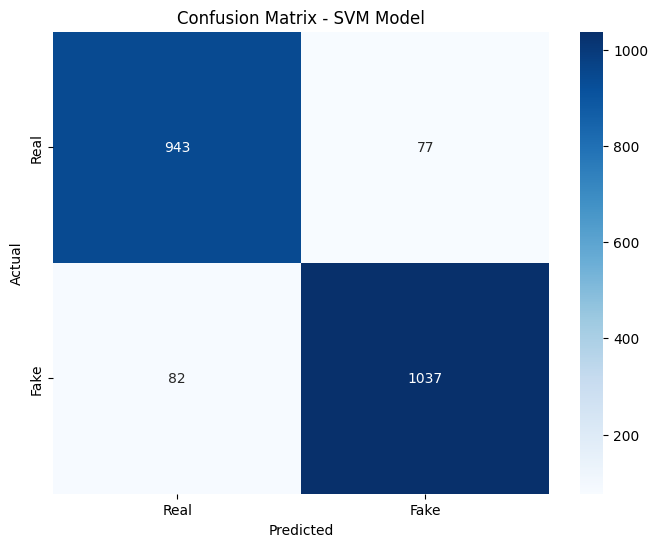

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - SVM Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [4]:
print("="*40)
print("   FINAL EVALUATION SUMMARY")
print("="*40)
print(f"Algorithm          : SVM (LinearSVC)")
print(f"Total Test Samples : {len(y_test)}")
print(f"Correct Predictions: {int(accuracy*len(y_test))}")
print(f"Model Accuracy     : {accuracy*100:.2f}%")
print("="*40)

   FINAL EVALUATION SUMMARY
Algorithm          : SVM (LinearSVC)
Total Test Samples : 2139
Correct Predictions: 1980
Model Accuracy     : 92.57%
